In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/SB/Downloads/logistics_dataset.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(5000, 14)
Order_ID                   object
Order_Date                 object
Carrier                    object
Route                      object
Region                     object
Shipment_Type              object
Promised_TAT_Days           int64
Actual_TAT_Days             int64
On_Time                      bool
In_Full                      bool
OTIF                         bool
Freight_Cost_INR          float64
Service_Failure_Reason     object
TAT_Delay                   int64
dtype: object
Order_ID                     0
Order_Date                   0
Carrier                      0
Route                        0
Region                       0
Shipment_Type                0
Promised_TAT_Days            0
Actual_TAT_Days              0
On_Time                      0
In_Full                      0
OTIF                         0
Freight_Cost_INR             0
Service_Failure_Reason    2668
TAT_Delay                    0
dtype: int64


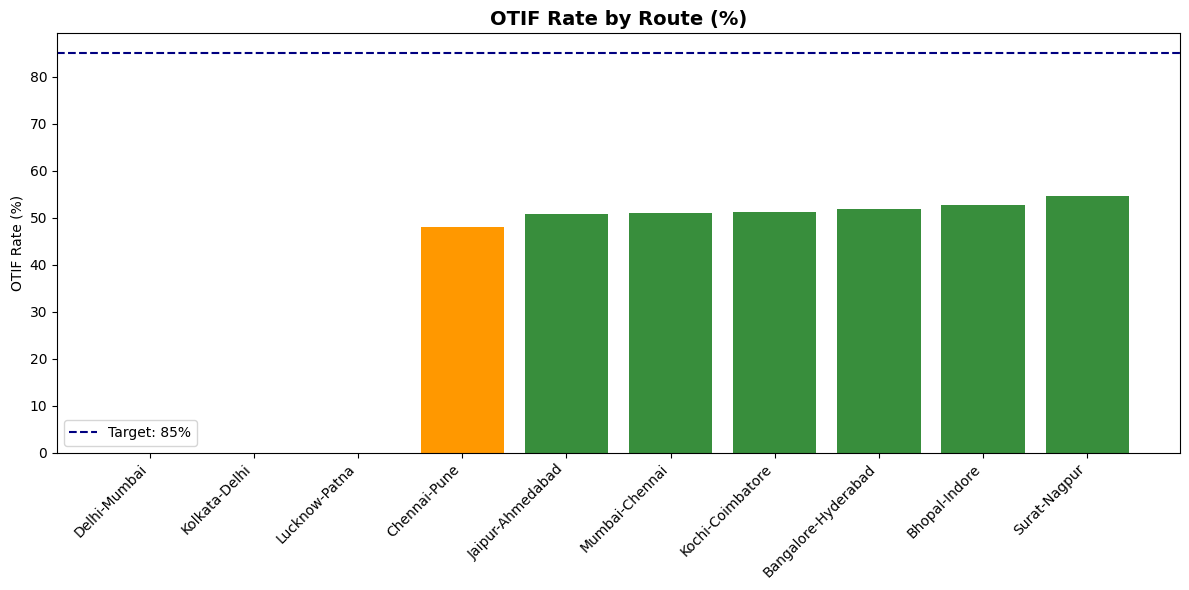

In [2]:
route_otif = df.groupby('Route')['OTIF'].mean().sort_values() * 100

plt.figure(figsize=(12, 6))
colors = ['#d32f2f' if x < 10 else '#ff9800' if x < 50 else '#388e3c' for x in route_otif.values]
bars = plt.bar(route_otif.index, route_otif.values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.title('OTIF Rate by Route (%)', fontsize=14, fontweight='bold')
plt.ylabel('OTIF Rate (%)')
plt.axhline(y=85, color='navy', linestyle='--', label='Target: 85%')
plt.legend()
plt.tight_layout()
plt.savefig('otif_by_route.png', dpi=150)
plt.show()

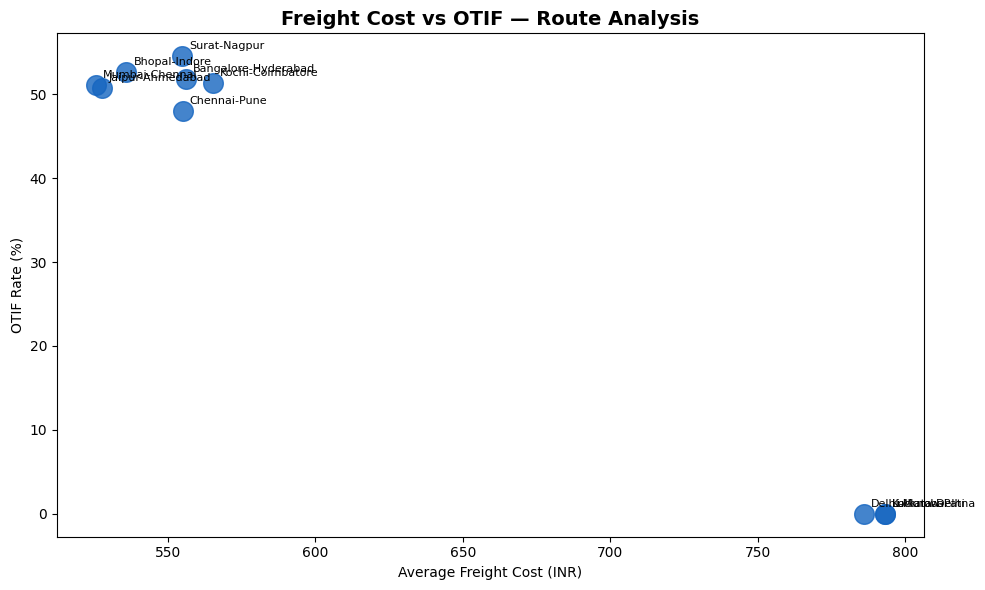

In [3]:
route_summary = df.groupby('Route').agg(
    OTIF_Pct=('OTIF', lambda x: x.mean()*100),
    Avg_Freight=('Freight_Cost_INR', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(route_summary['Avg_Freight'], route_summary['OTIF_Pct'],
            s=200, c='#1565c0', alpha=0.8)
for _, row in route_summary.iterrows():
    plt.annotate(row['Route'], (row['Avg_Freight'], row['OTIF_Pct']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.xlabel('Average Freight Cost (INR)')
plt.ylabel('OTIF Rate (%)')
plt.title('Freight Cost vs OTIF — Route Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cost_vs_otif.png', dpi=150)
plt.show()

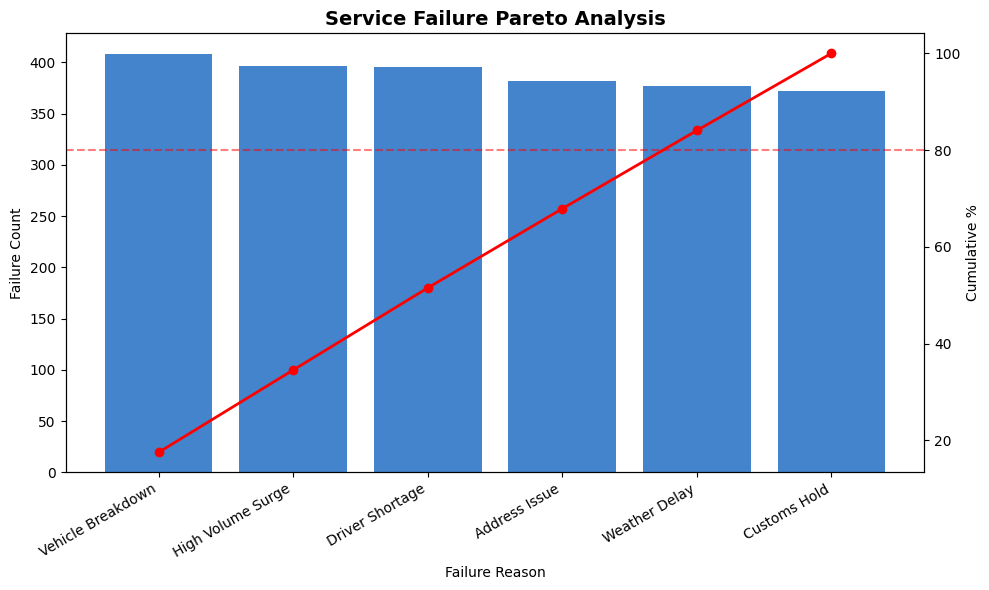

In [4]:
failures = df[df['Service_Failure_Reason'] != 'None']['Service_Failure_Reason'].value_counts()
cumulative_pct = failures.cumsum() / failures.sum() * 100

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(failures.index, failures.values, color='#1565c0', alpha=0.8)
ax1.set_ylabel('Failure Count')
ax1.set_xlabel('Failure Reason')
plt.xticks(rotation=30, ha='right')

ax2 = ax1.twinx()
ax2.plot(failures.index, cumulative_pct.values, 'ro-', linewidth=2)
ax2.set_ylabel('Cumulative %')
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.5)

plt.title('Service Failure Pareto Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('failure_pareto.png', dpi=150)
plt.show()

In [5]:
carrier_summary = df.groupby('Carrier').agg(
    OTIF_Pct=('OTIF', lambda x: round(x.mean()*100, 1)),
    Avg_TAT_Delay=('Actual_TAT_Days', lambda x: round((x - df.loc[x.index, 'Promised_TAT_Days']).mean(), 2)),
    Avg_Freight=('Freight_Cost_INR', lambda x: round(x.mean(), 0)),
    Total_Shipments=('Order_ID', 'count')
).reset_index()

print("\n=== CARRIER PERFORMANCE SCORECARD ===")
print(carrier_summary.sort_values('OTIF_Pct').to_string(index=False))


=== CARRIER PERFORMANCE SCORECARD ===
   Carrier  OTIF_Pct  Avg_TAT_Delay  Avg_Freight  Total_Shipments
      DTDC      16.1           1.85        678.0              984
XpressBees      17.1           1.78        679.0             1025
 Delhivery      48.1           0.87        573.0             1012
  BlueDart      48.3           0.85        586.0              967
     Ekart      50.0           0.92        585.0             1012
